In [12]:
# Class Imbalance >> When One Class Has higher Percentage
#Handeling Class Imbalance :
    #Upsampling
    #DownSampling
    #SMOTE

In [13]:
import pandas as pd
import numpy as np

np.random.seed(1)# for Reproducibility Of result

no_sample=1000
class_0_ratio=0.9
no_class_0=int(no_sample*class_0_ratio)
no_class_1=100

In [14]:
no_class_0,no_class_1

(900, 100)

In [15]:
class_0={'feature1':np.random.normal(0,1,no_class_0),
        'feature2': np.random.normal(0,1,no_class_0),
        'target':[0]*no_class_0}

In [16]:
class_0=pd.DataFrame(class_0)
class_0

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [17]:
class_1=pd.DataFrame({'feature1': np.random.normal(3,1,no_class_1),
                      'feature2': np.random.normal(3,1,no_class_1),
                      'target':[1]*no_class_1})

In [18]:
class_1

,feature1,feature2,target
0,1.692029,3.933630,1
1,4.472396,1.236225,1
2,3.074876,2.589783,1
3,1.213065,2.546333,1
4,3.165211,2.410570,1
...,...,...,...
95,3.213026,3.188583,1
96,2.195458,3.560918,1
97,2.353418,2.078341,1
98,4.138173,3.647375,1


In [19]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)


In [20]:
df

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [21]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [22]:
#Upsampling
df_minority=df[df.target==1]
df_majority=df[df.target==0]

In [23]:
df_majority

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [24]:
df_minority

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [25]:
# replace>> if replace is truw ,it means data points can be repeated

In [26]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True,n_samples=len(df_majority))

In [27]:
df_minority_upsampled.shape

(900, 3)

In [28]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [29]:
df_upsampled.target.value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [30]:
# Down Sampleing
df_minority

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [31]:
df_majority

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [32]:
df_majority_downsampled=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=1)

In [33]:
df_majority_downsampled

,feature1,feature2,target
860,-0.977773,0.872579,0
880,0.309817,1.835870,0
874,0.050317,0.146532,0
780,0.677808,-0.859827,0
525,0.713049,0.320971,0
...,...,...,...
494,-1.579156,2.711950,0
255,-1.044589,0.522655,0
672,0.410266,0.683356,0
481,-1.114871,-0.800787,0


In [34]:
pd.concat([df_minority,df_majority_downsampled])

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
494,-1.579156,2.711950,0
255,-1.044589,0.522655,0
672,0.410266,0.683356,0
481,-1.114871,-0.800787,0


In [35]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])

In [36]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

In [37]:
from sklearn.datasets import make_classification

X,Y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.90])

In [38]:
X

array([[-0.61212066,  1.57999205],
       [ 0.14971151, -0.02877929],
       [-0.37789943,  0.7944008 ],
       ...,
       [-1.29584647,  0.13293852],
       [-0.94169029,  0.5490333 ],
       [-0.49766468,  0.65496759]], shape=(1000, 2))

In [39]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [42]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(Y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)

In [43]:
final_df

,f1,f2,target
0,-0.612121,1.579992,0
1,0.149712,-0.028779,0
2,-0.377899,0.794401,0
3,-0.711326,0.560354,0
4,-1.481766,1.512872,0
...,...,...,...
995,-1.005736,0.788515,0
996,-2.269091,1.762625,0
997,-1.295846,0.132939,1
998,-0.941690,0.549033,0


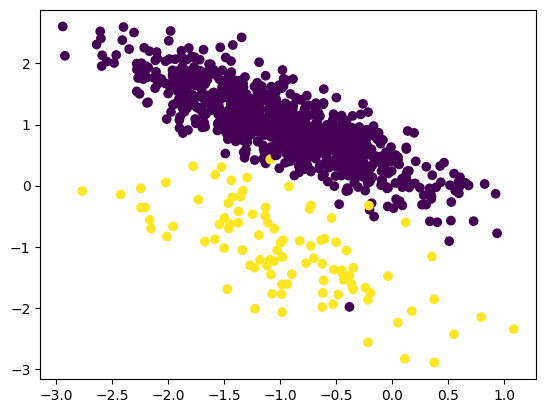

In [44]:
# Visulatization
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [46]:
!pip install imblearn

In [47]:
from imblearn.over_sampling import SMOTE
oversample=SMOTE()

In [49]:
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [55]:
x.shape

(1800, 2)

In [56]:
y.shape

(1800,)

In [62]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(Y,columns=['target'])
Smote_df=pd.concat([df1,df2],axis=1)

In [64]:
Smote_df

,f1,f2,target
0,-0.612121,1.579992,0
1,0.149712,-0.028779,0
2,-0.377899,0.794401,0
3,-0.711326,0.560354,0
4,-1.481766,1.512872,0
...,...,...,...
995,-1.005736,0.788515,0
996,-2.269091,1.762625,0
997,-1.295846,0.132939,1
998,-0.941690,0.549033,0


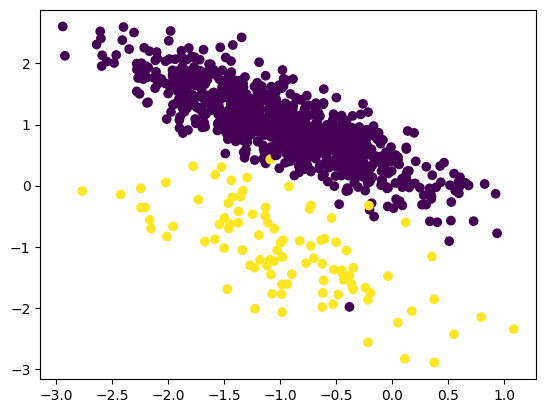

In [65]:
import matplotlib.pyplot as plt
plt.scatter(Smote_df['f1'],Smote_df['f2'],c=Smote_df['target'])